In [2]:
import pandas as pd

df = pd.read_csv("hospital_waiting_time.csv")

df.head()


,Patient_ID,Department,Appointment_Time,Registration_Time,Consultation_Time,Discharge_Time,Doctor,Day,Appointment_Type
0,P001,General Medicine,2026-09-01 14:00:00,2026-09-01 14:12:00,2026-09-01 14:43:00,2026-09-01 14:55:00,Dr. Ravi,Tuesday,Follow-up
1,P002,Dermatology,2026-09-02 10:00:00,2026-09-02 10:26:00,2026-09-02 10:41:00,2026-09-02 11:13:00,Dr. Karthik,Wednesday,Routine Checkup
2,P003,Orthopedics,2026-09-03 11:30:00,2026-09-03 11:40:00,2026-09-03 12:22:00,2026-09-03 12:55:00,Dr. Kumar,Thursday,Emergency
3,P004,Pediatrics,2026-09-04 11:00:00,2026-09-04 11:36:00,2026-09-04 12:19:00,2026-09-04 12:31:00,Dr. Suresh,Friday,Emergency
4,P005,Pediatrics,2026-09-05 15:00:00,2026-09-05 15:36:00,2026-09-05 16:05:00,2026-09-05 16:37:00,Dr. Divya,Saturday,Routine Checkup


In [3]:
df.shape

(100, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         100 non-null    object
 1   Department         100 non-null    object
 2   Appointment_Time   100 non-null    object
 3   Registration_Time  100 non-null    object
 4   Consultation_Time  100 non-null    object
 5   Discharge_Time     100 non-null    object
 6   Doctor             100 non-null    object
 7   Day                100 non-null    object
 8   Appointment_Type   100 non-null    object
dtypes: object(9)
memory usage: 7.2+ KB


In [5]:
df.isnull().sum()

,0
Patient_ID,0
Department,0
Appointment_Time,0
Registration_Time,0
Consultation_Time,0
Discharge_Time,0
Doctor,0
Day,0
Appointment_Type,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [9]:
time_columns = [
    "Appointment_Time",
    "Registration_Time",
    "Consultation_Time",
    "Discharge_Time"
]

for col in time_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Patient_ID         100 non-null    object        
 1   Department         100 non-null    object        
 2   Appointment_Time   100 non-null    datetime64[ns]
 3   Registration_Time  100 non-null    datetime64[ns]
 4   Consultation_Time  100 non-null    datetime64[ns]
 5   Discharge_Time     100 non-null    datetime64[ns]
 6   Doctor             100 non-null    object        
 7   Day                100 non-null    object        
 8   Appointment_Type   100 non-null    object        
dtypes: datetime64[ns](4), object(5)
memory usage: 7.2+ KB


In [12]:
invalid_times = df[
    (df["Registration_Time"] < df["Appointment_Time"]) |
    (df["Consultation_Time"] < df["Registration_Time"]) |
    (df["Discharge_Time"] < df["Consultation_Time"])
]

invalid_times

,Patient_ID,Department,Appointment_Time,Registration_Time,Consultation_Time,Discharge_Time,Doctor,Day,Appointment_Type


In [14]:
df["Registration_Wait"] = (
    df["Registration_Time"] - df["Appointment_Time"]
).dt.total_seconds() / 60

In [15]:
df["Doctor_Wait"] = (
    df["Consultation_Time"] - df["Registration_Time"]
).dt.total_seconds() / 60

In [16]:
df["Total_Wait"] = (
    df["Consultation_Time"] - df["Appointment_Time"]
).dt.total_seconds() / 60

In [17]:
df[
    [
        "Patient_ID",
        "Registration_Wait",
        "Doctor_Wait",
        "Total_Wait"
    ]
].head(10)

,Patient_ID,Registration_Wait,Doctor_Wait,Total_Wait
0,P001,12.0,31.0,43.0
1,P002,26.0,15.0,41.0
2,P003,10.0,42.0,52.0
3,P004,36.0,43.0,79.0
4,P005,36.0,29.0,65.0
5,P006,10.0,25.0,35.0
6,P007,15.0,40.0,55.0
7,P008,17.0,45.0,62.0
8,P009,9.0,25.0,34.0
9,P010,16.0,29.0,45.0


In [18]:
df["Consultation_Duration"] = (
    df["Discharge_Time"] - df["Consultation_Time"]
).dt.total_seconds() / 60

In [19]:
df[
    [
        "Patient_ID",
        "Consultation_Time",
        "Discharge_Time",
        "Consultation_Duration"
    ]
].head(10)

,Patient_ID,Consultation_Time,Discharge_Time,Consultation_Duration
0,P001,2026-09-01 14:43:00,2026-09-01 14:55:00,12.0
1,P002,2026-09-02 10:41:00,2026-09-02 11:13:00,32.0
2,P003,2026-09-03 12:22:00,2026-09-03 12:55:00,33.0
3,P004,2026-09-04 12:19:00,2026-09-04 12:31:00,12.0
4,P005,2026-09-05 16:05:00,2026-09-05 16:37:00,32.0
5,P006,2026-09-06 16:35:00,2026-09-06 17:07:00,32.0
6,P007,2026-09-07 13:25:00,2026-09-07 14:07:00,42.0
7,P008,2026-09-08 11:47:00,2026-09-08 12:08:00,21.0
8,P009,2026-09-09 10:49:00,2026-09-09 11:22:00,33.0
9,P010,2026-09-10 15:30:00,2026-09-10 15:49:00,19.0


In [20]:
df[
    (df["Registration_Wait"] < 0) |
    (df["Doctor_Wait"] < 0) |
    (df["Total_Wait"] < 0) |
    (df["Consultation_Duration"] < 0)
]

,Patient_ID,Department,Appointment_Time,Registration_Time,Consultation_Time,Discharge_Time,Doctor,Day,Appointment_Type,Registration_Wait,Doctor_Wait,Total_Wait,Consultation_Duration


In [21]:
df[
    [
        "Registration_Wait",
        "Doctor_Wait",
        "Total_Wait",
        "Consultation_Duration"
    ]
].describe()

,Registration_Wait,Doctor_Wait,Total_Wait,Consultation_Duration
count,100.000000,100.000000,100.000000,100.00000
mean,20.330000,37.070000,57.400000,26.01000
std,8.556473,14.091515,18.416615,8.69633
min,5.000000,6.000000,11.000000,10.00000
25%,14.000000,26.750000,45.750000,20.00000
50%,20.000000,34.500000,56.000000,27.00000
75%,26.250000,47.000000,68.250000,33.00000
max,36.000000,77.000000,107.000000,48.00000


In [22]:
print("Average Registration Wait:",
      df["Registration_Wait"].mean())

print("Average Doctor Wait:",
      df["Doctor_Wait"].mean())

print("Average Total Wait:",
      df["Total_Wait"].mean())

print("Average Consultation Duration:",
      df["Consultation_Duration"].mean())

Average Registration Wait: 20.33
Average Doctor Wait: 37.07
Average Total Wait: 57.4
Average Consultation Duration: 26.01


In [23]:
print("Median Registration Wait:",
      df["Registration_Wait"].median())

print("Median Doctor Wait:",
      df["Doctor_Wait"].median())

print("Median Total Wait:",
      df["Total_Wait"].median())

Median Registration Wait: 20.0
Median Doctor Wait: 34.5
Median Total Wait: 56.0


In [24]:
department_analysis = df.groupby("Department").agg(
    Patients=("Patient_ID", "count"),
    Avg_Registration_Wait=("Registration_Wait", "mean"),
    Avg_Doctor_Wait=("Doctor_Wait", "mean"),
    Avg_Total_Wait=("Total_Wait", "mean"),
    Median_Total_Wait=("Total_Wait", "median")
).sort_values(
    "Avg_Total_Wait",
    ascending=False
)

department_analysis

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait,Median_Total_Wait
Department,,,,,
Cardiology,16,20.500000,47.625000,68.125000,63.0
Pediatrics,19,23.526316,40.578947,64.105263,64.0
Orthopedics,17,18.941176,39.941176,58.882353,58.0
General Medicine,24,20.416667,33.250000,53.666667,53.0
Dermatology,24,18.583333,29.041667,47.625000,47.0


In [25]:
doctor_analysis = df.groupby("Doctor").agg(
    Patients=("Patient_ID", "count"),
    Avg_Registration_Wait=("Registration_Wait", "mean"),
    Avg_Doctor_Wait=("Doctor_Wait", "mean"),
    Avg_Total_Wait=("Total_Wait", "mean")
).sort_values(
    "Avg_Total_Wait",
    ascending=False
)

doctor_analysis

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait
Doctor,,,,
Dr. Arun,6,21.666667,51.000000,72.666667
Dr. Divya,9,22.777778,47.666667,70.444444
Dr. Priya,10,19.800000,45.600000,65.400000
Dr. Kumar,6,18.333333,43.500000,61.833333
Dr. Suresh,10,24.200000,34.200000,58.400000
Dr. Meena,11,19.272727,38.000000,57.272727
Dr. Anitha,9,21.111111,35.666667,56.777778
Dr. Ravi,15,20.000000,31.800000,51.800000
Dr. Karthik,14,20.142857,30.571429,50.714286


In [26]:
appointment_analysis = df.groupby("Appointment_Type").agg(
    Patients=("Patient_ID", "count"),
    Avg_Registration_Wait=("Registration_Wait", "mean"),
    Avg_Doctor_Wait=("Doctor_Wait", "mean"),
    Avg_Total_Wait=("Total_Wait", "mean"),
    Median_Total_Wait=("Total_Wait", "median")
).sort_values(
    "Avg_Total_Wait",
    ascending=False
)

appointment_analysis

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait,Median_Total_Wait
Appointment_Type,,,,,
Emergency,21,23.571429,51.904762,75.476190,78.0
New Patient,29,21.137931,34.379310,55.517241,55.0
Routine Checkup,29,18.586207,34.068966,52.655172,52.0
Follow-up,21,18.380952,30.095238,48.476190,49.0


In [28]:
df["Is_Weekend"] = df["Day"].isin(
    ["Saturday", "Sunday"]
)

In [29]:
weekend_analysis = df.groupby("Is_Weekend").agg(
    Patients=("Patient_ID", "count"),
    Avg_Registration_Wait=("Registration_Wait", "mean"),
    Avg_Doctor_Wait=("Doctor_Wait", "mean"),
    Avg_Total_Wait=("Total_Wait", "mean")
)

weekend_analysis

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait
Is_Weekend,,,,
False,72,19.902778,38.083333,57.986111
True,28,21.428571,34.464286,55.892857


In [30]:
day_analysis = df.groupby("Day").agg(
    Patients=("Patient_ID", "count"),
    Avg_Total_Wait=("Total_Wait", "mean"),
    Avg_Doctor_Wait=("Doctor_Wait", "mean"),
    Avg_Registration_Wait=("Registration_Wait", "mean")
).sort_values(
    "Avg_Total_Wait",
    ascending=False
)

day_analysis

,Patients,Avg_Total_Wait,Avg_Doctor_Wait,Avg_Registration_Wait
Day,,,,
Friday,14,67.214286,41.285714,25.928571
Thursday,14,60.928571,42.285714,18.642857
Sunday,14,60.714286,38.214286,22.500000
Monday,14,58.357143,40.857143,17.500000
Tuesday,15,54.733333,34.866667,19.866667
Saturday,14,51.071429,30.714286,20.357143
Wednesday,15,49.533333,31.800000,17.733333


In [31]:
df["Appointment_Hour"] = df["Appointment_Time"].dt.hour

In [32]:
hour_analysis = df.groupby("Appointment_Hour").agg(
    Patients=("Patient_ID", "count"),
    Avg_Total_Wait=("Total_Wait", "mean"),
    Avg_Doctor_Wait=("Doctor_Wait", "mean"),
    Avg_Registration_Wait=("Registration_Wait", "mean")
).sort_index()

hour_analysis

,Patients,Avg_Total_Wait,Avg_Doctor_Wait,Avg_Registration_Wait
Appointment_Hour,,,,
9,14,38.071429,23.214286,14.857143
10,18,61.444444,36.500000,24.944444
11,18,67.777778,46.055556,21.722222
12,12,57.000000,41.750000,15.250000
14,15,67.066667,43.133333,23.933333
15,14,57.000000,34.714286,22.285714
16,9,43.666667,29.111111,14.555556


In [33]:
df["Appointment_Hour"].value_counts().sort_index()

,count
Appointment_Hour,
9,14
10,18
11,18
12,12
14,15
15,14
16,9


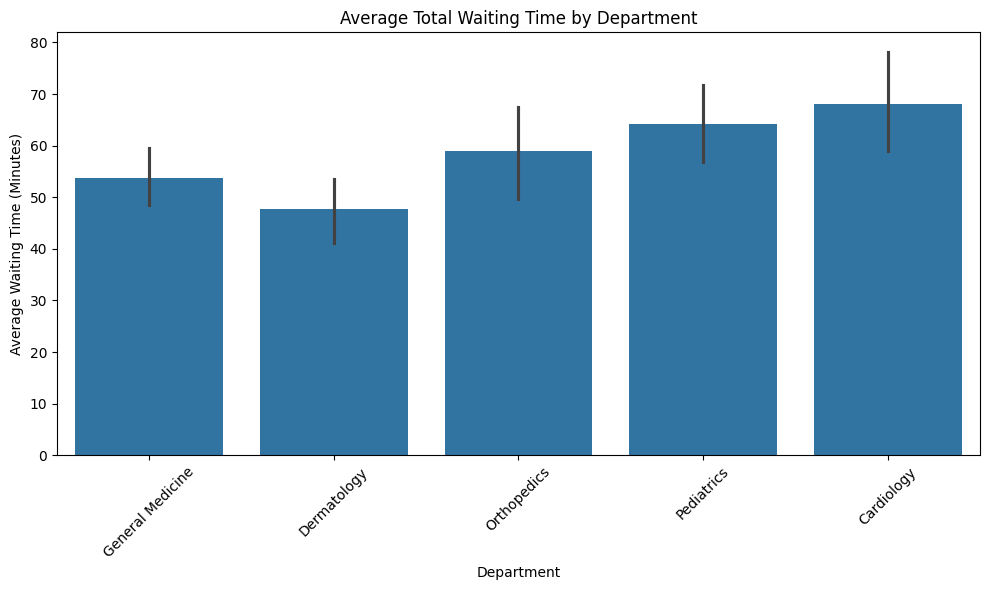

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Department",
    y="Total_Wait",
    estimator="mean"
)

plt.title("Average Total Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (Minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

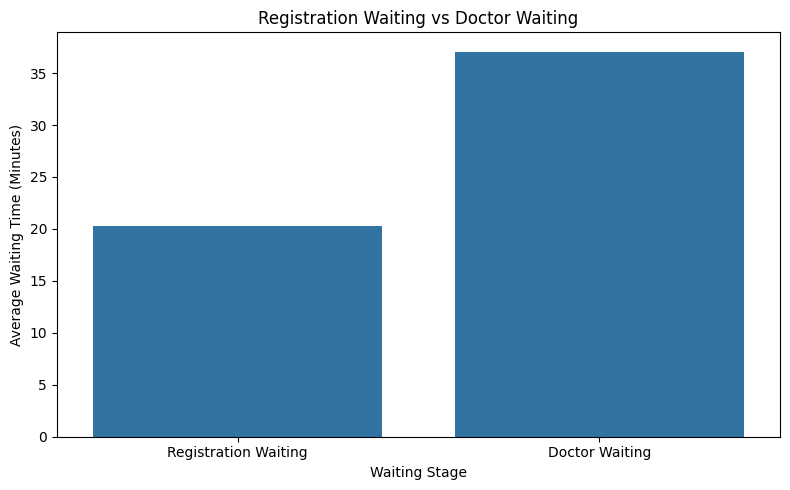

In [35]:
waiting_comparison = pd.DataFrame({
    "Waiting Type": [
        "Registration Waiting",
        "Doctor Waiting"
    ],
    "Average Minutes": [
        df["Registration_Wait"].mean(),
        df["Doctor_Wait"].mean()
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=waiting_comparison,
    x="Waiting Type",
    y="Average Minutes"
)

plt.title("Registration Waiting vs Doctor Waiting")
plt.xlabel("Waiting Stage")
plt.ylabel("Average Waiting Time (Minutes)")

plt.tight_layout()
plt.show()

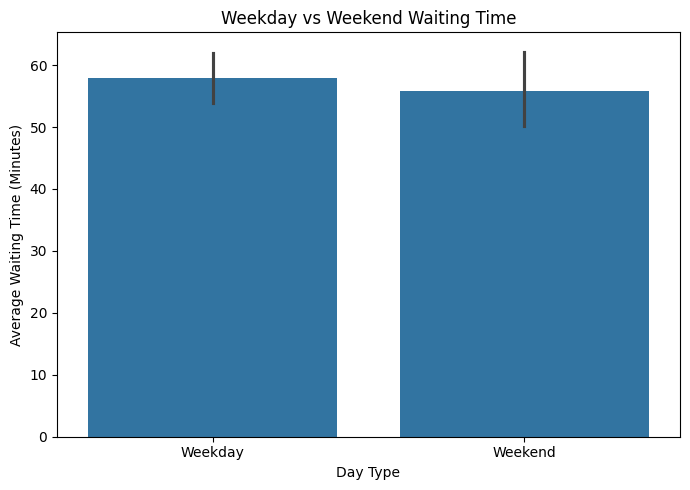

In [36]:
weekend_plot = df.copy()

weekend_plot["Day_Type"] = weekend_plot["Day"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=weekend_plot,
    x="Day_Type",
    y="Total_Wait",
    estimator="mean"
)

plt.title("Weekday vs Weekend Waiting Time")
plt.xlabel("Day Type")
plt.ylabel("Average Waiting Time (Minutes)")

plt.tight_layout()
plt.show()

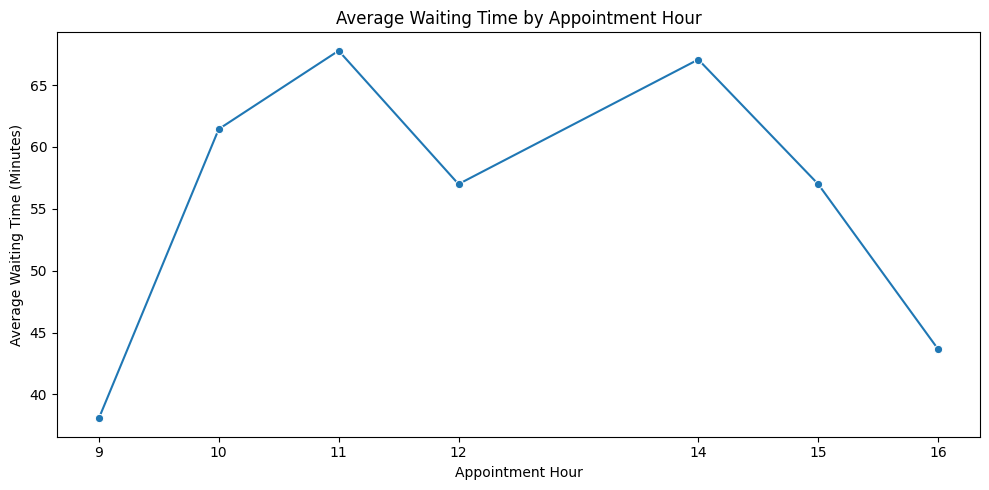

In [37]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_analysis,
    x=hour_analysis.index,
    y="Avg_Total_Wait",
    marker="o"
)

plt.title("Average Waiting Time by Appointment Hour")
plt.xlabel("Appointment Hour")
plt.ylabel("Average Waiting Time (Minutes)")

plt.xticks(hour_analysis.index)

plt.tight_layout()
plt.show()

In [38]:
df.groupby("Department")["Total_Wait"].mean().sort_values(ascending=False)

,Total_Wait
Department,
Cardiology,68.125000
Pediatrics,64.105263
Orthopedics,58.882353
General Medicine,53.666667
Dermatology,47.625000


In [39]:
df.groupby("Is_Weekend")["Total_Wait"].mean()

,Total_Wait
Is_Weekend,
False,57.986111
True,55.892857


In [40]:
df.groupby("Appointment_Hour")["Total_Wait"].mean()

,Total_Wait
Appointment_Hour,
9,38.071429
10,61.444444
11,67.777778
12,57.000000
14,67.066667
15,57.000000
16,43.666667


In [42]:
model_df = df[
    [
        "Department",
        "Doctor",
        "Day",
        "Appointment_Type",
        "Appointment_Hour",
        "Is_Weekend",
        "Total_Wait"
    ]
].copy()

In [43]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        "Department",
        "Doctor",
        "Day",
        "Appointment_Type"
    ],
    drop_first=True
)

In [44]:
X = model_df.drop("Total_Wait", axis=1)
y = model_df["Total_Wait"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [47]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 10.710166666666666
RMSE: 13.406816560574281
R² Score: 0.10757792419001622
